# Data Cleaning: 
Data cleaning is the process of preparing raw data by detecting and correcting errors so it can be effectively used for analysis. It is a foundational step in data preprocessing that ensures datasets are suitable for analytical, statistical and machine learning tasks.

## Step 1: Import all important libaries

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


## Step 2: Load dataset

In [3]:
df=pd.read_csv("../Data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 3: Find missing values, duplicates, and incorrect/ inconistenat data

In [7]:
print("Basic statistics:\n")
print(df.describe())
print("=="*40)
print("Basic info:\n")
df.info()
print("=="*40)
print("Missing values:\n")
df.isnull().sum()
print("=="*40)
print("Find Missing values as percentage:\n",round((df.isnull().sum() / df.shape[0]) * 100, 2))
print("=="*40)
print("Duplicate values:\n")
df.duplicated().sum()
print("=="*40)
print("Columns:\n",df.columns.tolist())


Basic statistics:

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
Basic info:



<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB
Missing values:

Find Missing values as percentage:
 PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            

## Step 4: Remove duplicates

In [4]:
print("duplicates before removing duplicates:\n",df.duplicated().sum())
df=df.drop_duplicates()
print("Duplicate values after removing duplicates:\n",df.duplicated().sum())


duplicates before removing duplicates:
 0
Duplicate values after removing duplicates:
 0


## Step 5: Identify Column data type

In [8]:
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:\n", cat_cols)
print("Numerical columns:\n", num_cols)

Categorical columns:
 ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical columns:
 ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


## Step 6: Count Unique Values

In [9]:
df[num_cols].nunique()

PassengerId    891
Survived         2
Pclass           3
Age             88
SibSp            7
Parch            7
Fare           248
dtype: int64

## Step 7: Drop Irrelevant or Data-Heavy Missing Columns

In [7]:
df = df.drop(columns=["Name", "Ticket", "Cabin"],errors="ignore")  
df.dropna(subset=["Embarked"], inplace=True)
df["Age"] = df["Age"].fillna(df["Age"].mean())
df.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


## Step 8: Detect Outliers with Box Plot

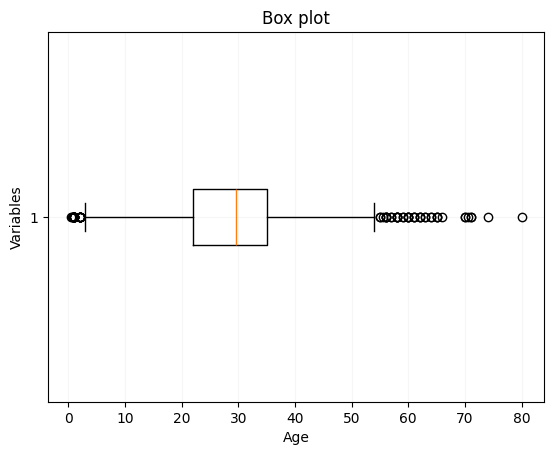

In [9]:
plt.boxplot(df["Age"],vert=False)
plt.ylabel("Variables")
plt.xlabel("Age")
plt.title("Box plot")
plt.grid(True,alpha=0.1)
plt.show()

## Step 9: Calculate Outlier Boundaries and Remove Them

In [10]:
mean=df["Age"].mean()
std=df["Age"].std()

lower_bound=mean-2*std
upper_bound=mean+2*std

print("Lower bound:",lower_bound)
print("Upper bound:",upper_bound)

df=df[(df["Age"] <= lower_bound) & (df["Age"] >= upper_bound)]


Lower bound: 3.7054001079256587
Upper bound: 55.57878528533277


# Step 10: Impute Missing Data Again if Any

In [11]:
df=df.fillna(df["Age"].mean())
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

## Step 11: Data validation and verification

In [ ]:
X=df.drop(["Survived"],axis=1)
Y=df[["Survived"]]
print("X Columns:",X.columns.tolist())
print("Y column :",Y.columns.tolist())

X Columns: ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Ycolumn : ['Survived']


##  DATA CLEANING MODULE COMPLETE!

The data cleaning process has been successfully completed. All missing values have been handled, duplicates removed, irrelevant columns dropped, and outliers addressed. The dataset is now clean, consistent, and ready for the model building phase.


### Final Dataset Overview:
- **Total Records:** 891 passengers
- **Features:** 8 columns (PassengerId, Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)
- **Target Variable:** Survived (Binary Classification: 0 = Died, 1 = Survived)
- **Data Quality:** No missing values |  No duplicates | No outliers


###  Target Distribution:
- **Survived (1):** 342 passengers (38.4%)
- **Died (0):** 549 passengers (61.6%)



###  Ready for Model Building!

The cleaned data can now be used for training various machine learning models including:

- **Logistic Regression** (Recommended for baseline)
- Decision Tree Classifier
- Random Forest Classifier
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)
- Naive Bayes Classifier
- Gradient Boosting (XGBoost/LightGBM)



###  Next Steps for Modeling:
1. Split data into training and testing sets (train_test_split)
2. Apply feature scaling (StandardScaler or MinMaxScaler)
3. Train multiple models and compare performance
4. Perform hyperparameter tuning for optimization
5. Evaluate using metrics: Accuracy, Precision, Recall, F1-Score, ROC-AUC
6. Save and export the best performing model
